In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("energy forecasting /energy_forecasting.csv")
df['period_end'] = pd.to_datetime(df['period_end'])
df.set_index('period_end', inplace=True)

In [ ]:
df_cleaned = df.drop(columns=['period', 'dni'], errors='ignore')
df_cleaned.interpolate(method='linear', inplace=True)
df_cleaned.ffill(inplace=True)

<ipython-input-4-91b63c26ac21>:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_cleaned.interpolate(method='linear', inplace=True)


In [ ]:
target_col = 'ghi'
data = df_cleaned[[target_col]].values

In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
n_steps_in = 24
n_steps_out = 6
n_features = 1

In [ ]:
def create_sequences(data, n_steps_in, n_steps_out):
    X, y = [], []
    for i in range(len(data) - n_steps_in - n_steps_out + 1):
        X.append(data[i:i+n_steps_in])
        y.append(data[i+n_steps_in:i+n_steps_in+n_steps_out])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, n_steps_in, n_steps_out)
X = X.reshape((X.shape[0], X.shape[1], n_features))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
model = Sequential([
Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_steps_in, n_features)),
MaxPooling1D(pool_size=2),
LSTM(100, activation='relu'),
Dense(n_steps_out)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,862 (261.18 KB)

 Trainable params: 66,862 (261.18 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

In [ ]:
history = model.fit(
X_train, y_train,
epochs=50,
batch_size=32,
validation_data=(X_test, y_test),
callbacks=[early_stop, checkpoint],
verbose=1
)

Epoch 1/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0240

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - loss: 0.0240 - val_loss: 0.0031
Epoch 2/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0024 - val_loss: 0.0027
Epoch 3/50
1094/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0019

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0019 - val_loss: 0.0023
Epoch 4/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 5/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0017

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 6/50
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016

...

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 10/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 11/50
1092/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 12/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 13/50
1094/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 14/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 15/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 16/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 17/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 18/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 19/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 20/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 21/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 22/50
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 0.0014 - val_loss: 0.0019


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
#loss = model.evaluate(X_test, y_test)
#print(f"Test Loss (MSE): {loss}")


y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))

mse = mean_squared_error(y_test_inv, y_pred_inv)
print(f"MSE: {mse:.2f}")

rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

variance = np.var(y_test_inv)
print(f"Variance of y_test: {variance:.2f}")

error_ratio = mse / variance
print(f"Relative Error Ratio (MSE/Variance): {error_ratio:.4f}")

r2 = r2_score(y_test_inv, y_pred_inv)
print(f"R² Score: {r2:.4f}")


274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
MSE: 1970.55
RMSE: 44.39
Variance of y_test: 107909.00
Relative Error Ratio (MSE/Variance): 0.0183
R² Score: 0.9817


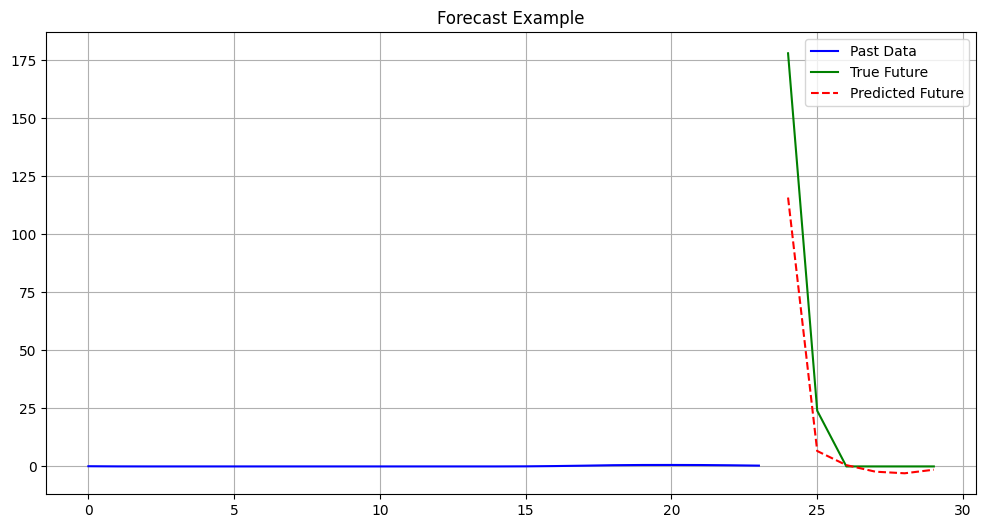

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(n_steps_in), X_test[0].flatten(), label='Past Data', color='blue')
plt.plot(range(n_steps_in, n_steps_in + n_steps_out), y_test_inv[:n_steps_out], label='True Future', color='green')
plt.plot(range(n_steps_in, n_steps_in + n_steps_out), y_pred_inv[:n_steps_out], label='Predicted Future', color='red', linestyle='dashed')
plt.title('Forecast Example')
plt.legend()
plt.grid(True)
plt.show()


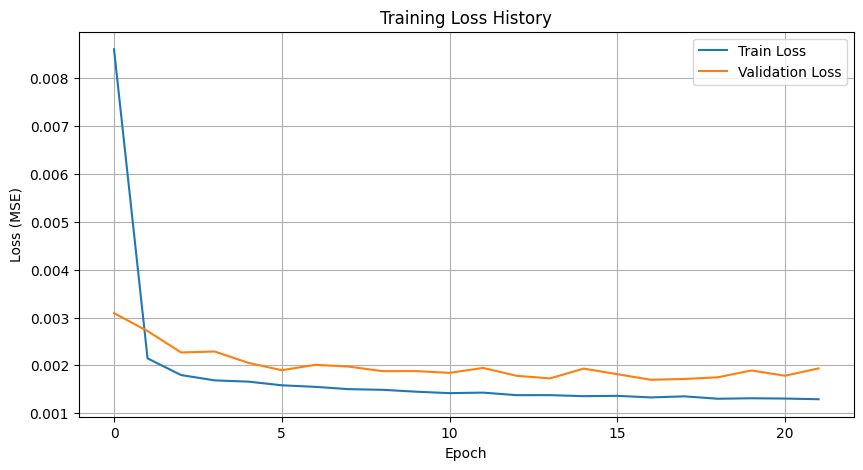

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

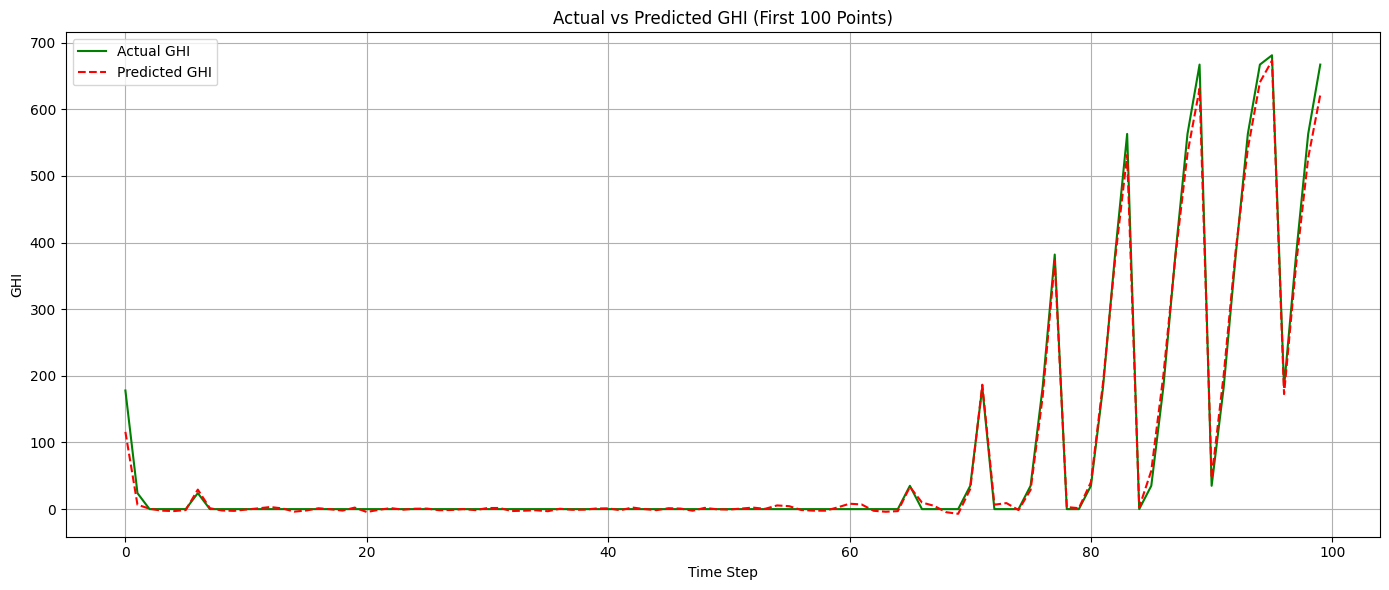

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv[:100], label='Actual GHI', color='green')
plt.plot(y_pred_inv[:100], label='Predicted GHI', color='red', linestyle='--')
plt.title('Actual vs Predicted GHI (First 100 Points)')
plt.xlabel('Time Step')
plt.ylabel('GHI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()